In [1]:
import pandas as pd
sales = pd.read_csv('../data/sales.csv')

In [2]:
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])


In [3]:
customer_sales = sales.dropna(
    subset=["Customer ID"]
).copy()

In [4]:
customer_summary = (
    customer_sales
    .groupby("Customer ID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Units=("Quantity", "sum"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
)


In [5]:
# Average Order Value
customer_summary["AOV"] = (
    customer_summary["Revenue"] /
    customer_summary["Orders"]
)


print("Customer Summary:")
print(customer_summary.head(10))

print("Shape:")
print(customer_summary.shape)

Customer Summary:
   Customer ID   Revenue  Orders  Units      First_Purchase  \
0      12346.0    372.86      11     70 2009-12-14 08:34:00   
1      12347.0   1323.32       2    828 2010-10-31 14:20:00   
2      12348.0    222.16       1    373 2010-09-27 14:59:00   
3      12349.0   2671.14       3    993 2010-04-29 13:20:00   
4      12351.0    300.93       1    261 2010-11-29 15:23:00   
5      12352.0    343.80       2    188 2010-11-12 10:20:00   
6      12353.0    317.76       1    192 2010-10-27 12:44:00   
7      12355.0    488.21       1    303 2010-05-21 11:59:00   
8      12356.0   3560.30       3   1825 2010-10-11 09:42:00   
9      12357.0  12079.99       2   3879 2010-11-16 10:05:00   

        Last_Purchase          AOV  
0 2010-06-28 13:53:00    33.896364  
1 2010-12-07 14:57:00   661.660000  
2 2010-09-27 14:59:00   222.160000  
3 2010-10-28 08:23:00   890.380000  
4 2010-11-29 15:23:00   300.930000  
5 2010-11-29 10:07:00   171.900000  
6 2010-10-27 12:44:00   317.7

In [6]:
top_customers = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

print("Top 10 Customers by Revenue:")
print(top_customers)

Top 10 Customers by Revenue:
      Customer ID    Revenue  Orders   Units      First_Purchase  \
4185      18102.0  349164.35      89  124216 2009-12-01 09:24:00   
1638      14646.0  248396.50      78  170342 2009-12-02 16:52:00   
1270      14156.0  196549.74     102  108105 2009-12-01 12:30:00   
1842      14911.0  152121.22     205   69709 2009-12-01 11:41:00   
939       13694.0  131443.19      94  125893 2009-12-04 15:26:00   
3746      17511.0   84541.17      31   55107 2009-12-02 10:52:00   
1953      15061.0   83284.38      86   51791 2009-12-01 12:18:00   
3130      16684.0   80489.21      27   54555 2009-12-07 12:56:00   
3179      16754.0   65500.07      29   63551 2010-03-08 11:32:00   
4067      17949.0   60117.60      74   30112 2009-12-02 11:07:00   

           Last_Purchase          AOV  
4185 2010-12-09 13:44:00  3923.194944  
1638 2010-11-30 16:28:00  3184.570513  
1270 2010-12-03 11:48:00  1926.958235  
1842 2010-12-09 12:17:00   742.054732  
939  2010-12-01 12:12:

In [7]:
top_orders = (
    customer_summary
    .sort_values("Orders", ascending=False)
    .head(10)
)

print("Top 10 Customers by Number of Orders:")
print(top_orders)

Top 10 Customers by Number of Orders:
      Customer ID    Revenue  Orders   Units      First_Purchase  \
1842      14911.0  152121.22     205   69709 2009-12-01 11:41:00   
3998      17850.0   51208.87     155   21052 2009-12-05 12:28:00   
251       12748.0   22457.90     144   13110 2009-12-04 17:31:00   
2135      15311.0   55942.74     121   32784 2009-12-01 11:21:00   
506       13089.0   57885.45     109   29130 2009-12-02 15:44:00   
1607      14606.0   18482.10     102    9287 2009-12-03 12:40:00   
1270      14156.0  196549.74     102  108105 2009-12-01 12:30:00   
939       13694.0  131443.19      94  125893 2009-12-04 15:26:00   
3991      17841.0   29562.02      91   14332 2009-12-02 15:41:00   
4185      18102.0  349164.35      89  124216 2009-12-01 09:24:00   

           Last_Purchase          AOV  
1842 2010-12-09 12:17:00   742.054732  
3998 2010-12-02 15:27:00   330.379806  
251  2010-12-09 13:22:00   155.957639  
2135 2010-12-09 14:15:00   462.336694  
506  2010-12-

In [8]:
## one-time vs repeat customers


customer_type = (
    customer_summary["Orders"]
    .apply(
        lambda x: "One-time"
        if x == 1
        else "Repeat"
    )
    .value_counts()
)

print("Customer Type:")
print(customer_type)

Customer Type:
Orders
Repeat      2893
One-time    1421
Name: count, dtype: int64


In [9]:
customer_type_percentage = (
    customer_type /
    customer_type.sum() * 100
)

print("Customer Type Percentage:")
print(customer_type_percentage)

Customer Type Percentage:
Orders
Repeat      67.060732
One-time    32.939268
Name: count, dtype: float64


In [10]:
customer_summary["Customer_Type"] = (
    customer_summary["Orders"]
    .apply(
        lambda x: "One-time"
        if x == 1
        else "Repeat"
    )
)

In [11]:
customer_type_revenue = (
    customer_summary
    .groupby("Customer_Type")
    .agg(
        Customers=("Customer ID", "count"),
        Revenue=("Revenue", "sum"),
        Orders=("Orders", "sum")
    )
    .reset_index()
)

print("Revenue by Customer Type:")
print(customer_type_revenue)

Revenue by Customer Type:
  Customer_Type  Customers      Revenue  Orders
0      One-time       1421   496304.474    1421
1        Repeat       2893  8301929.270   17794


In [12]:
print("Customer Revenue Statistics:")

print(
    customer_summary["Revenue"].describe()
)

Customer Revenue Statistics:
count      4314.000000
mean       2039.460766
std        8909.797773
min           0.000000
25%         307.105000
50%         700.405000
75%        1713.297500
max      349164.350000
Name: Revenue, dtype: float64


In [13]:
zero_revenue_customers = customer_summary[
    customer_summary["Revenue"] == 0
]

print(
    "Customers with zero revenue:",
    len(zero_revenue_customers)
)

Customers with zero revenue: 2


In [14]:
print(
    zero_revenue_customers.head()
)

      Customer ID  Revenue  Orders  Units      First_Purchase  \
1233      14103.0      0.0       1      5 2010-02-12 14:58:00   
1775      14827.0      0.0       1      5 2010-02-12 15:47:00   

           Last_Purchase  AOV Customer_Type  
1233 2010-02-12 14:58:00  0.0      One-time  
1775 2010-02-12 15:47:00  0.0      One-time  


In [15]:
analysis_date = customer_summary["Last_Purchase"].max() + pd.Timedelta(days=1)

In [16]:
# Removing customers with zero revenue
customer_summary = customer_summary[
    customer_summary["Revenue"] > 0
].copy()

In [17]:
## RFM analysis
rfm = customer_summary[
    [
        "Customer ID",
        "Last_Purchase",
        "Orders",
        "Revenue"
    ]
].copy()

In [18]:
rfm["Recency"] = (
    analysis_date - rfm["Last_Purchase"]
).dt.days

In [19]:
rfm["Frequency"] = rfm["Orders"]

In [20]:
rfm["Monetary"] = rfm["Revenue"]

In [21]:
print("RFM Analysis:")
print(rfm.head(10))


print("RFM Statistics:")
print(
    rfm[
        ["Recency", "Frequency", "Monetary"]
    ].describe()
)

RFM Analysis:
   Customer ID       Last_Purchase  Orders   Revenue  Recency  Frequency  \
0      12346.0 2010-06-28 13:53:00      11    372.86      165         11   
1      12347.0 2010-12-07 14:57:00       2   1323.32        3          2   
2      12348.0 2010-09-27 14:59:00       1    222.16       74          1   
3      12349.0 2010-10-28 08:23:00       3   2671.14       43          3   
4      12351.0 2010-11-29 15:23:00       1    300.93       11          1   
5      12352.0 2010-11-29 10:07:00       2    343.80       11          2   
6      12353.0 2010-10-27 12:44:00       1    317.76       44          1   
7      12355.0 2010-05-21 11:59:00       1    488.21      203          1   
8      12356.0 2010-11-24 12:24:00       3   3560.30       16          3   
9      12357.0 2010-11-16 14:29:00       2  12079.99       24          2   

   Monetary  
0    372.86  
1   1323.32  
2    222.16  
3   2671.14  
4    300.93  
5    343.80  
6    317.76  
7    488.21  
8   3560.30  
9  12079.

In [22]:
## rfm scoring


rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)


print("RFM Scores:")
print(
    rfm[
        [
            "Customer ID",
            "Recency",
            "Frequency",
            "Monetary",
            "R_Score",
            "F_Score",
            "M_Score"
        ]
    ].head(20)
)

RFM Scores:
    Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score
0       12346.0      165         11    372.86       2       5       2
1       12347.0        3          2   1323.32       5       2       4
2       12348.0       74          1    222.16       2       1       1
3       12349.0       43          3   2671.14       3       3       5
4       12351.0       11          1    300.93       5       1       2
5       12352.0       11          2    343.80       5       2       2
6       12353.0       44          1    317.76       3       1       2
7       12355.0      203          1    488.21       1       1       2
8       12356.0       16          3   3560.30       4       3       5
9       12357.0       24          2  12079.99       4       2       5
10      12358.0       11          3   2719.01       5       3       5
11      12359.0       61          6   2563.36       3       4       5
12      12360.0       15          5   1590.83       5       4       4
13      

In [23]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

print("RFM Scores:")
print(
    rfm[
        [
            "Customer ID",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM_Score"
        ]
    ].head(20)
)

RFM Scores:
    Customer ID R_Score F_Score M_Score RFM_Score
0       12346.0       2       5       2       252
1       12347.0       5       2       4       524
2       12348.0       2       1       1       211
3       12349.0       3       3       5       335
4       12351.0       5       1       2       512
5       12352.0       5       2       2       522
6       12353.0       3       1       2       312
7       12355.0       1       1       2       112
8       12356.0       4       3       5       435
9       12357.0       4       2       5       425
10      12358.0       5       3       5       535
11      12359.0       3       4       5       345
12      12360.0       5       4       4       544
13      12361.0       2       3       2       232
14      12362.0       1       1       1       111
15      12366.0       1       1       3       113
16      12368.0       1       1       3       113
17      12369.0       3       3       4       334
18      12370.0       1       3       

In [24]:
print("RFM Score Distribution:")

print(
    rfm["RFM_Score"]
    .value_counts()
    .sort_index()
)

RFM Score Distribution:
RFM_Score
111    202
112    105
113     37
114     11
115      3
      ... 
545     36
552      2
553     11
554     95
555    349
Name: count, Length: 117, dtype: int64


In [25]:
print("Average metrics by RFM Score:")

print(
    rfm.groupby("RFM_Score", observed=True)[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .sort_values("Monetary", ascending=False)
)

Average metrics by RFM Score:
              Recency  Frequency      Monetary
RFM_Score                                     
555          6.501433  18.667622  11624.995367
145        238.000000   4.666667   8751.621667
125        259.750000   1.250000   6770.977500
155        214.875000  10.250000   6590.662500
425         30.666667   1.666667   6512.870000
...               ...        ...           ...
121        267.548611   1.055556    147.056042
111        274.341584   1.000000    142.490396
211        117.932584   1.000000    137.481685
511          8.739130   1.000000    132.758261
351         57.000000   9.000000     97.400000

[117 rows x 3 columns]


In [26]:
## creating understandable customer segments

def segment_customer(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"

    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalists"

    elif r >= 4 and f == 1:
        return "New Customers"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"

    else:
        return "Needs Attention"


rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [27]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

print("Customer Segments:")
print(segment_summary)

Customer Segments:
                     Customers      Revenue  Avg_Recency  Avg_Frequency  \
Segment                                                                   
Champions                  926  5712430.697    13.672786      11.676026   
Loyal Customers            432   827091.522    41.217593       5.546296   
Needs Attention           1028   668218.313    95.627432       1.779183   
Can't Lose Them            216   664359.021   126.773148       5.921296   
Potential Loyalists        450   372137.340    18.544444       2.284444   
At Risk                    293   317009.220   146.522184       2.877133   
Lost                       830   186255.161   220.521687       1.071084   
New Customers              137    50732.470    19.481752       1.000000   

                     Avg_Monetary  
Segment                            
Champions             6168.931638  
Loyal Customers       1914.563708  
Needs Attention        650.017814  
Can't Lose Them       3075.736208  
Potential Loya

In [28]:
segment_summary["Revenue_Share"] = (
    segment_summary["Revenue"]
    / segment_summary["Revenue"].sum()
    * 100
)

print("Customer Segments with Revenue Share:")
print(segment_summary)

Customer Segments with Revenue Share:
                     Customers      Revenue  Avg_Recency  Avg_Frequency  \
Segment                                                                   
Champions                  926  5712430.697    13.672786      11.676026   
Loyal Customers            432   827091.522    41.217593       5.546296   
Needs Attention           1028   668218.313    95.627432       1.779183   
Can't Lose Them            216   664359.021   126.773148       5.921296   
Potential Loyalists        450   372137.340    18.544444       2.284444   
At Risk                    293   317009.220   146.522184       2.877133   
Lost                       830   186255.161   220.521687       1.071084   
New Customers              137    50732.470    19.481752       1.000000   

                     Avg_Monetary  Revenue_Share  
Segment                                           
Champions             6168.931638      64.927017  
Loyal Customers       1914.563708       9.400654  
Needs A

In [29]:
segment_summary["Customer_Share"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
)

print(
    segment_summary[
        [
            "Customers",
            "Customer_Share",
            "Revenue",
            "Revenue_Share"
        ]
    ]
)

                     Customers  Customer_Share      Revenue  Revenue_Share
Segment                                                                   
Champions                  926       21.474954  5712430.697      64.927017
Loyal Customers            432       10.018553   827091.522       9.400654
Needs Attention           1028       23.840445   668218.313       7.594914
Can't Lose Them            216        5.009276   664359.021       7.551050
Potential Loyalists        450       10.435993   372137.340       4.229682
At Risk                    293        6.794991   317009.220       3.603101
Lost                       830       19.248609   186255.161       2.116961
New Customers              137        3.177180    50732.470       0.576621


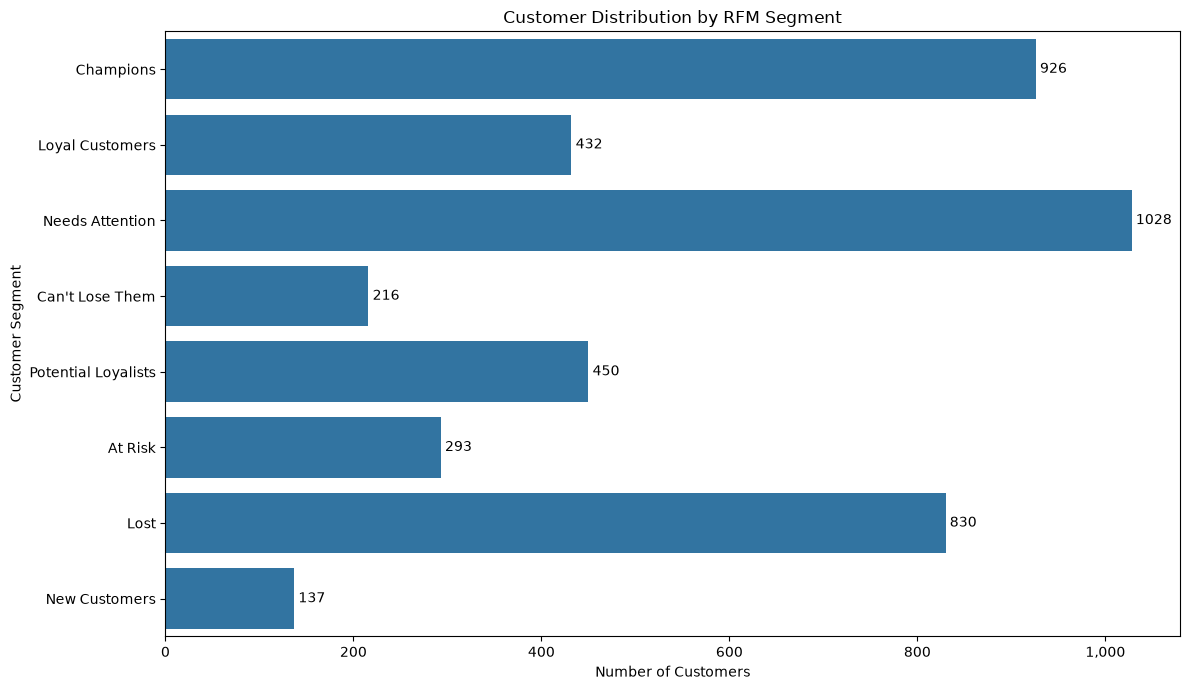

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=segment_summary,
    x="Customers",
    y="Segment"
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

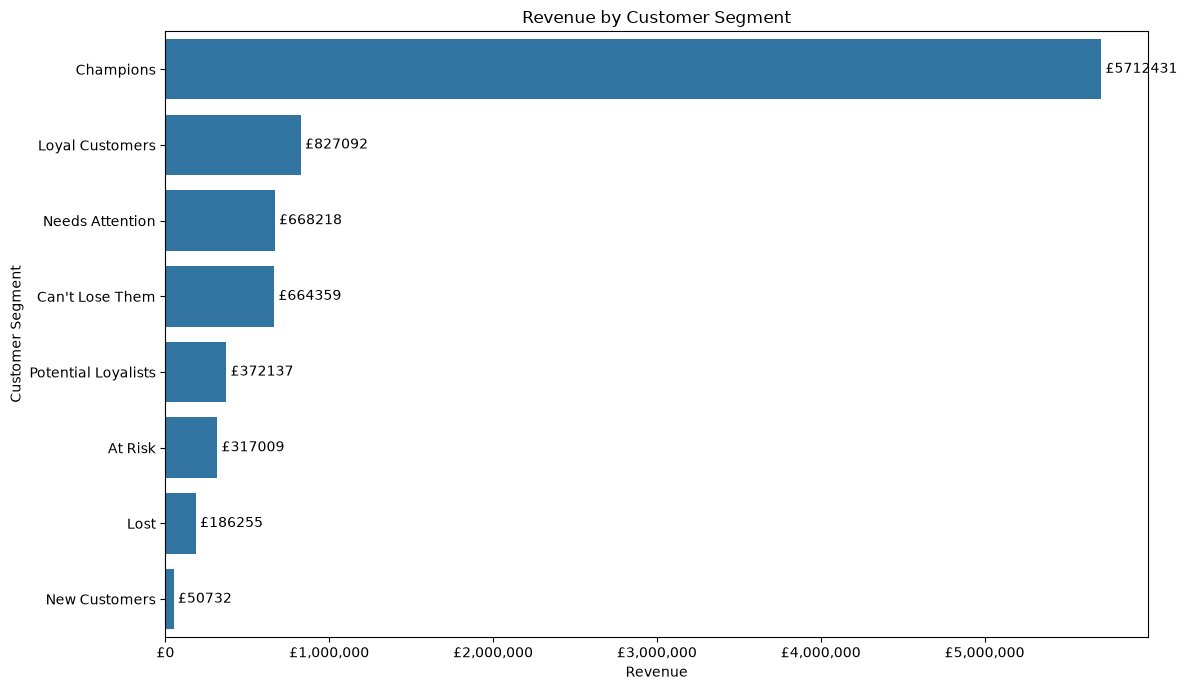

In [31]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=segment_summary.sort_values("Revenue", ascending=False),
    x="Revenue",
    y="Segment"
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="£%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/revenue_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

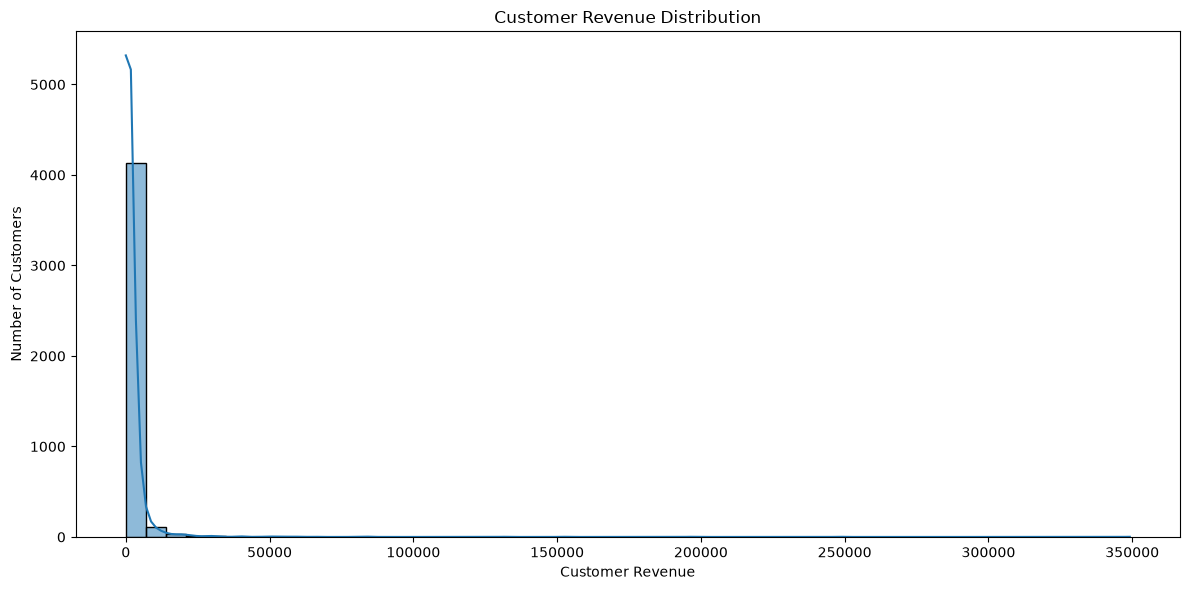

In [32]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=rfm,
    x="Monetary",
    bins=50,
    kde=True
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../outputs/customer_revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

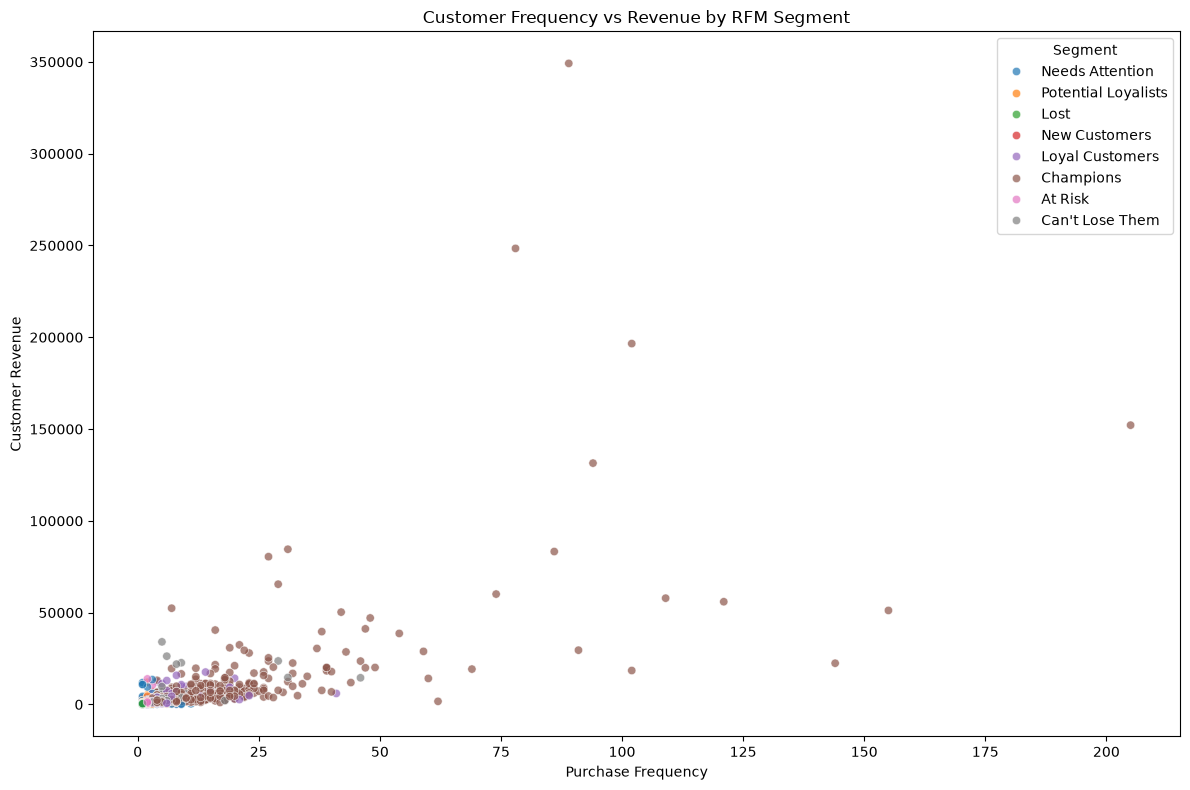

In [33]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    alpha=0.7
)

plt.title("Customer Frequency vs Revenue by RFM Segment")
plt.xlabel("Purchase Frequency")
plt.ylabel("Customer Revenue")

plt.tight_layout()

plt.savefig(
    "../outputs/rfm_frequency_vs_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()